In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc

df_moves = pd.read_parquet(r'..\df_moves6.parquet')

df_moves = df_moves.drop(columns=['E1', 'E2', 'E3', 'E4', 'E5'])

In [2]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'Judgment_Raw', 'Is_Error',
       'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal',
       'Remain_Time', 'Time_Group', 'Move_Time', 'Game_Length', 'Progress',
       'Relative_Stage(temp)', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'Cog_Speed'],
      dtype='object')

In [3]:
df_moves.head()

,uid,Move_Idx,Player,Color,E,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,...,S,P_model(Global=10.0cp),S(Global=10.0cp),P_model(Global=50.0cp),S(Global=50.0cp),P_model(Global=100.0cp),S(Global=100.0cp),P_model(Global=150.0cp),S(Global=150.0cp),Cog_Speed
0,34,1,Dennis Wagner,White,33.0,-,0,0,3.0,6.0,...,1.203,0.65,0.63,0.53,0.92,0.51,0.96,0.51,0.97,5.00
1,34,2,Petar Ratkovic,Black,36.0,-,0,0,3.0,4.0,...,1.396,0.60,0.74,0.52,0.94,0.51,0.97,0.51,0.98,1.25
2,34,3,Dennis Wagner,White,30.0,-,0,0,6.0,7.0,...,1.199,0.67,0.58,0.53,0.90,0.52,0.95,0.51,0.97,3.04
3,34,4,Petar Ratkovic,Black,44.0,-,0,0,14.0,38.0,...,1.243,0.98,0.03,0.68,0.55,0.59,0.75,0.56,0.83,380.00
4,34,5,Dennis Wagner,White,32.0,-,0,0,12.0,15.0,...,1.165,0.82,0.29,0.57,0.80,0.54,0.90,0.52,0.93,50.00


### Summary of Fitting Parameters


| ELO Group | A     | τ     | x₀   | A_err  | τ_err | x₀_err | Max CI Width | d_max | min_cnt |
| --------- | ----- | ----- | ---- | ------ | ----- | ------ | ------------ | ----- | ------- |
| ≥3000     | 0.886 | 169.1 | -8.7 | 0.0024 | 2.94  | 1.91   | 0.0109       | 700   | 50      |
| 2800–3000 | 0.880 | 174.4 | 7.1  | 0.0020 | 2.24  | 1.34   | 0.0085       | 700   | 50      |
| 2600–2800 | 0.871 | 172.9 | 29.6 | 0.0018 | 1.91  | 1.10   | 0.0069       | 700   | 80      |
| 2400–2600 | 0.861 | 172.4 | 41.7 | 0.0019 | 1.86  | 1.07   | 0.0069       | 700   | 100     |
| 2200–2400 | 0.851 | 173.5 | 53.8 | 0.0023 | 2.21  | 1.28   | 0.0085       | 700   | 100     |
| 2000–2200 | 0.836 | 169.5 | 63.4 | 0.0034 | 3.17  | 1.88   | 0.0129       | 700   | 50      |
| <2000     | 0.828 | 168.3 | 78.7 | 0.0113 | 6.71  | 4.90   | 0.0176       | 700   | 50      |


# 关于Forced Move的处理
## Δ & S & P = NaN

In [4]:
forced_count = (df_moves['Is_Forced'] == 1).sum()
print(f'数据集中所有强制走子的数量为{forced_count}')

数据集中所有强制走子的数量为462336


In [5]:
cols_to_check = ['P_model', 'S', 'P_model(Global=10.0cp)', 'S(Global=10.0cp)', 'Δ']
cols_to_check = [c for c in cols_to_check if c in df_moves.columns]

print("================ 异常值统计 ================")
for col in cols_to_check:
    # 统计 NaN 的数量
    nan_count = df_moves[col].isna().sum()
    # 统计 Inf 或 -Inf 的数量
    inf_count = np.isinf(df_moves[col]).sum()
    print(f"列 [{col}]:\t NaN 数量 = {nan_count:,} \t Inf 数量 = {inf_count:,}")

# 用 Group Specific 的 P_model 和 S 来做基础过滤 提取包含异常值的行
mask_anomalies = (
    df_moves['P_model'].isna() | np.isinf(df_moves['P_model']) |
    df_moves['S'].isna() | np.isinf(df_moves['S'])
)

df_anomalies = df_moves[mask_anomalies]

print(f"\n================ 异常值数据采样 ================")
print(f"总共发现 {len(df_anomalies):,} 行带有异常值的记录。")

if len(df_anomalies) > 0:
    display_cols = ['uid', 'Move_Idx', 'ELO', 'ELO_Group', 'Δ', 'A', 'P_model', 'S', 'Is_Forced']
    display_cols = [c for c in display_cols if c in df_anomalies.columns]
    
    print("\n前 15 行异常数据：")
    print(df_anomalies[display_cols].head(35))

================ 异常值统计 ================
列 [P_model]:	 NaN 数量 = 462,336 	 Inf 数量 = 0
列 [S]:	 NaN 数量 = 462,336 	 Inf 数量 = 0
列 [P_model(Global=10.0cp)]:	 NaN 数量 = 462,336 	 Inf 数量 = 0
列 [S(Global=10.0cp)]:	 NaN 数量 = 462,336 	 Inf 数量 = 0
列 [Δ]:	 NaN 数量 = 462,336 	 Inf 数量 = 0

================ 异常值数据采样 ================
总共发现 462,336 行带有异常值的记录。

前 15 行异常数据：
      uid  Move_Idx     ELO  ELO_Group   Δ  P_model   S  Is_Forced
215    37        44  2245.0  2200-2400 NaN      NaN NaN          1
456    41        60  2319.0  2200-2400 NaN      NaN NaN          1
779    47        47  2512.0  2400-2600 NaN      NaN NaN          1
1011   50        61  2304.0  2200-2400 NaN      NaN NaN          1
1475   57        72  2368.0  2200-2400 NaN      NaN NaN          1
1760   62        47  2450.0  2400-2600 NaN      NaN NaN          1
1813   63        52  2387.0  2200-2400 NaN      NaN NaN          1
2300   72        53  2601.0  2600-2800 NaN      NaN NaN          1
2502   75        61  3153.0     >=3000 NaN   

In [6]:
(df_moves['Progress'] == 1).sum()

np.int64(708594)

In [7]:
cols = ['uid','Move_Idx','Is_Error', 'Is_Blunder', 'Progress','Δ', 'Δi', 'P_model', 'S', 'Is_Forced', 'Is_Optimal']
cols = [c for c in cols if c in df_moves.columns]

df_moves[(df_moves['Progress'] == 1) & (df_moves['Is_Forced'] == 1)][cols].head(20)

,uid,Move_Idx,Is_Error,Is_Blunder,Progress,Δ,Δi,P_model,S,Is_Forced,Is_Optimal
2978,83,71,0,0,1.0,NaN,0.0,NaN,NaN,1,1
6154,129,58,0,0,1.0,NaN,0.0,NaN,NaN,1,1
46860,576,194,0,0,1.0,NaN,0.0,NaN,NaN,1,1
52490,666,51,0,0,1.0,NaN,9.0,NaN,NaN,1,1
55119,703,95,0,0,1.0,NaN,0.0,NaN,NaN,1,1
82363,1021,72,0,0,1.0,NaN,-1.0,NaN,NaN,1,1
85039,1051,90,0,0,1.0,NaN,0.0,NaN,NaN,1,1
120246,1425,73,0,0,1.0,NaN,0.0,NaN,NaN,1,1
125671,1502,55,0,0,1.0,NaN,0.0,NaN,NaN,1,1
145876,1733,77,0,0,1.0,NaN,0.0,NaN,NaN,1,1


# 画S P 的分布 （排除了强制走子）

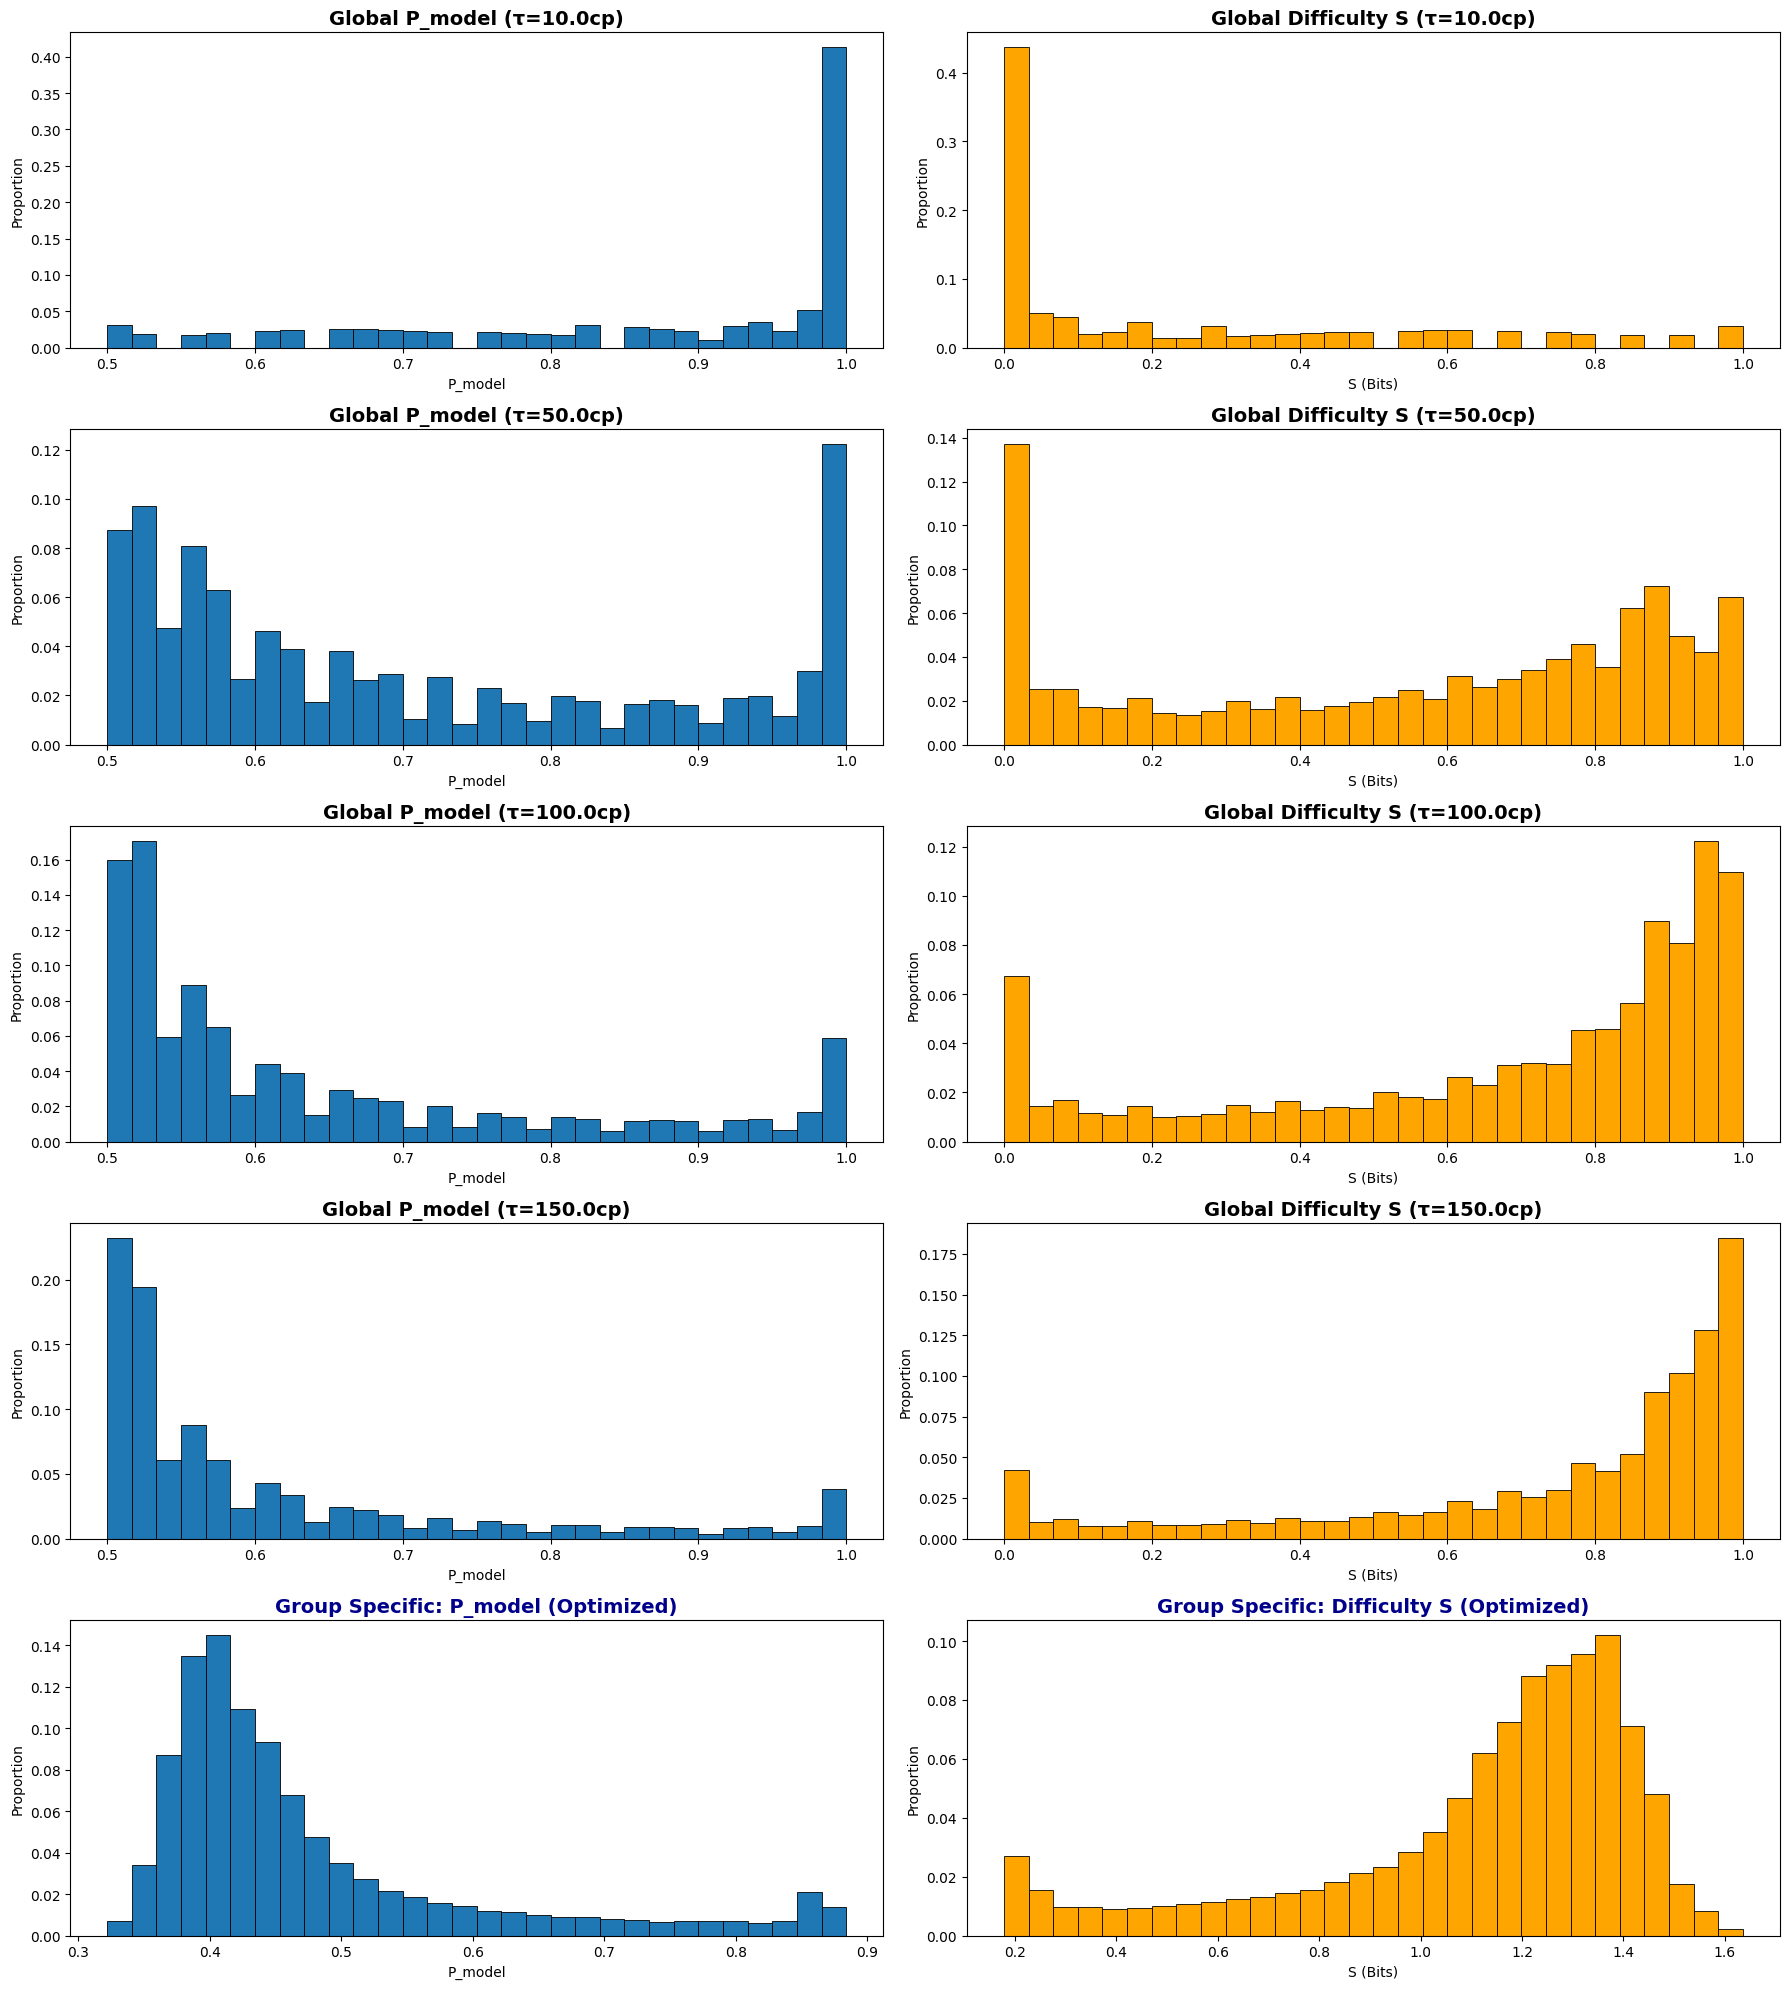

In [8]:
GLOBAL_τ_List = [10.0, 50.0, 100.0, 150.0]
not_forced_mask = (df_moves['Is_Forced'] != 1).to_numpy()

# 计算总行数
n_rows = len(GLOBAL_τ_List) + 1
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
# 列名匹配函数
def get_column_name(df, base_name, τ):
    col_float = f'{base_name}(Global={τ}cp)'
    col_int = f'{base_name}(Global={int(τ)}cp)'
    return col_float if col_float in df.columns else col_int


def fast_hist(ax, data, bins=30, color=None):
    counts, edges = np.histogram(data, bins=bins)
    prob = counts / counts.sum()
    width = np.diff(edges)
    ax.bar(edges[:-1], prob, width=width, align="edge", color=color, edgecolor="black", linewidth=0.6)

# Global τ
for i, τ in enumerate(GLOBAL_τ_List):

    p_col = get_column_name(df_moves, 'P_model', τ)
    s_col = get_column_name(df_moves, 'S', τ)

    if s_col not in df_moves.columns:
        print(f"跳过: 找不到列 {s_col}")
        continue

    # P
    if p_col in df_moves.columns:
        data = df_moves[p_col].to_numpy()[not_forced_mask]
        fast_hist(axes[i,0], data)
        axes[i,0].set_title(
            f'Global P_model (τ={τ}cp)',
            fontsize=14,
            fontweight='bold'
        )
        axes[i,0].set_xlabel('P_model')
        axes[i,0].set_ylabel('Proportion')
    # S
    if s_col in df_moves.columns:
        data = df_moves[s_col].to_numpy()[not_forced_mask]
        fast_hist(axes[i,1], data, color='orange')
        axes[i,1].set_title(
            f'Global Difficulty S (τ={τ}cp)',
            fontsize=14,
            fontweight='bold'
        )
        axes[i,1].set_xlabel('S (Bits)')
        axes[i,1].set_ylabel('Proportion')
# Group Specific
last_row_idx = n_rows - 1
if 'P_model' in df_moves.columns:
    data = df_moves['P_model'].to_numpy()[not_forced_mask]
    fast_hist(axes[last_row_idx,0], data)
    axes[last_row_idx,0].set_title(
        'Group Specific: P_model (Optimized)',fontsize=14,fontweight='bold',color='darkblue')
    axes[last_row_idx,0].set_xlabel('P_model')
    axes[last_row_idx,0].set_ylabel('Proportion')

    data = df_moves['S'].to_numpy()[not_forced_mask]
    fast_hist(axes[last_row_idx,1], data, color='orange')
    axes[last_row_idx,1].set_title('Group Specific: Difficulty S (Optimized)',fontsize=14,fontweight='bold',color='darkblue')
    axes[last_row_idx,1].set_xlabel('S (Bits)')
    axes[last_row_idx,1].set_ylabel('Proportion')


plt.tight_layout()
plt.show()

### 解释新的P_model为什么会有<0.5的值
以 <2000 分的低分段组为例，他们的 $x_0 = 91.5$。    
假设这个玩家当前面对一个极为基础的局面（即复杂度 $\Delta = 0$），代入公式看看会发生什么：     
$-(\Delta - x_0) = -(0 - 91.5) = 91.5$      
指数部分变成了正数：$91.5 / 181.3 \approx 0.505$$e^{0.505} \approx 1.657$     
分母变成了 $1 + 1.657 = 2.657$    
最终 $P_{model} = 0.855 / 2.657 \approx$ 0.32

# P_model 和 P_emp 的关系曲线  （排除了强制走子）

<>:73: SyntaxWarning: invalid escape sequence '\h'
<>:73: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_7352\1752035409.py:73: SyntaxWarning: invalid escape sequence '\h'
  label=f'Global Model ($\hat{{P}}$ @ $\\tau$={tau_val})')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_7352\1752035409.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['Delta_Bin'] = (plot_df[delta_col] // 15) * 15
C:\Users\Administrator\AppData\Local\Temp\ipykernel_7352\1752035409.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

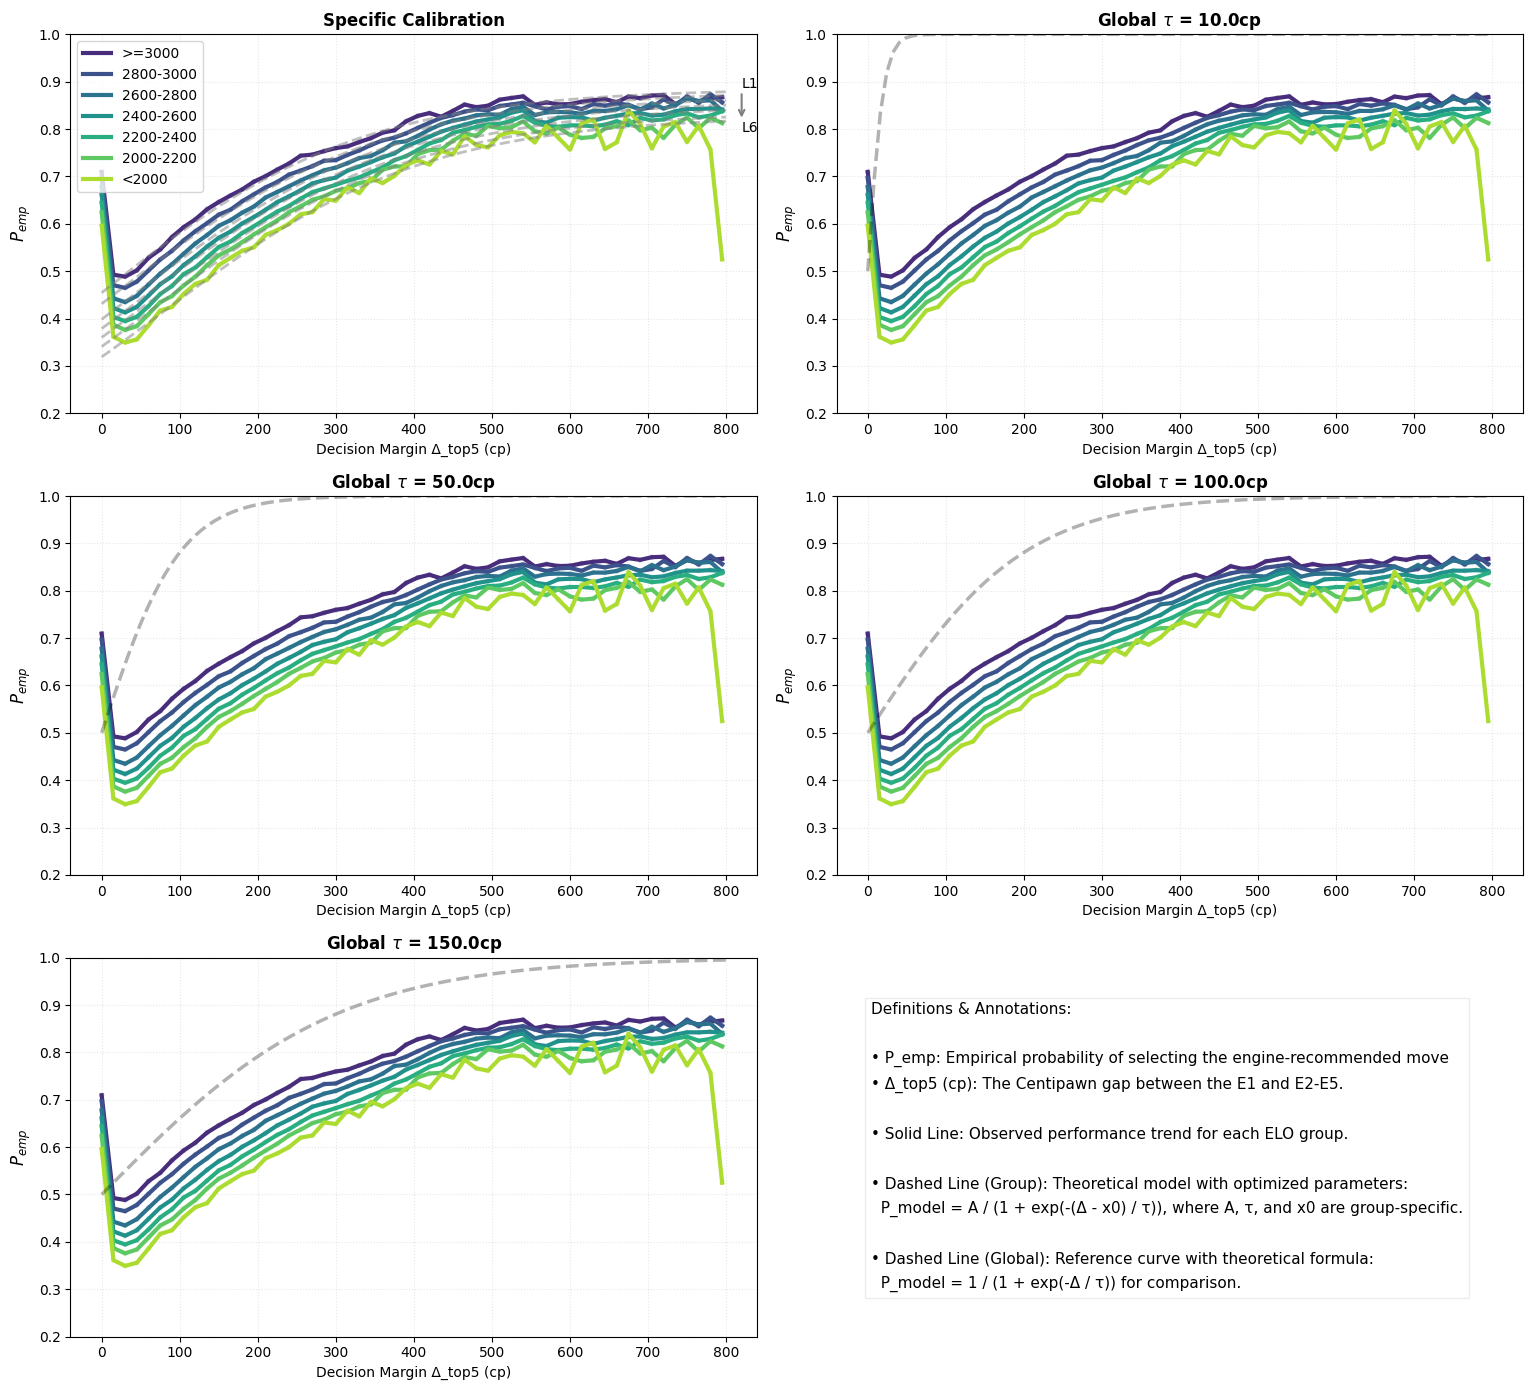

In [9]:
elo_order=['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000'] # 确保图例和曲线颜色从高到低一致
# distinct_palette = sns.color_palette("Set1", len(elo_order))
distinct_palette = sns.color_palette("viridis", len(elo_order))
# 基于较大数据集拟合结果
elo_params = {
    '>=3000':      {'A': 0.886, 'τ': 169.1, 'x0': -8.7},
    '2800-3000':   {'A': 0.880, 'τ': 174.4, 'x0': 7.1},
    '2600-2800':   {'A': 0.871, 'τ': 172.9, 'x0': 29.6},
    '2400-2600':   {'A': 0.861, 'τ': 172.4, 'x0': 41.7},
    '2200-2400':   {'A': 0.851, 'τ': 173.5, 'x0': 53.8},
    '2000-2200':   {'A': 0.836, 'τ': 169.5, 'x0': 63.4},
    '<2000':       {'A': 0.828, 'τ': 168.3, 'x0': 78.7}
}

def plot_delta_performance(data, delta_col, title, ax, tau_val=None, is_group_specific=False):
    """
    支持单条 Global 参考线或多条 Elo-specific 参考线
    """
    # 高速聚合逻辑保持不变
    plot_df = data[(data[delta_col] >= 0) & (data[delta_col] <= 800)]
    plot_df['Delta_Bin'] = (plot_df[delta_col] // 15) * 15
    
    agg_data = (plot_df.groupby(['ELO_Group', 'Delta_Bin'])['Is_Optimal']
                .mean().reset_index()
                .rename(columns={'Is_Optimal': 'P_emp'}))

    # 实测数据
    for i, group in enumerate(elo_order):
        group_data = agg_data[agg_data['ELO_Group'] == group]
        color = distinct_palette[i]
        # 实测散点
        ax.scatter(group_data['Delta_Bin'], group_data['P_emp'], 
                   color=color, s=15, alpha=0.3, edgecolor='none')
        # 实测平滑趋势线
        sns.lineplot(data=group_data, x='Delta_Bin', y='P_emp', 
                     color=color, linewidth=3.0, ax=ax, 
                     label=group if is_group_specific else None)

    # 理论参考线
    x_ref = np.linspace(0, 800, 100)
    
    if is_group_specific:
        # 画理论曲线
        for i, group in enumerate(elo_order):
            A = elo_params[group]['A']
            tau = elo_params[group]['τ']
            x0 = elo_params[group]['x0']

            y_ref = A / (1 + np.exp(-(x_ref - x0) / tau))
            ax.plot(x_ref,y_ref,color='grey',linestyle='--',alpha=0.5,linewidth=2)

        ax.set_title(title, fontsize=12, fontweight='bold')
        # 求最上和最下曲线位置 写图例
        A_top = elo_params[elo_order[0]]['A']
        tau_top = elo_params[elo_order[0]]['τ']
        x0_top = elo_params[elo_order[0]]['x0']
        A_bottom = elo_params[elo_order[-1]]['A']
        tau_bottom = elo_params[elo_order[-1]]['τ']
        x0_bottom = elo_params[elo_order[-1]]['x0']
        label_x = x_ref[-1] + 20
        y_top = A_top / (1 + np.exp(-(label_x - x0_top) / tau_top))
        y_bottom = A_bottom / (1 + np.exp(-(label_x - x0_bottom) / tau_bottom))
        # 写 L1 和 L6
        ax.text(label_x, y_top, "L1", fontsize=10, ha='left', va='bottom')
        ax.text(label_x, y_bottom, "L6", fontsize=10, ha='left', va='top')
        # 画箭头
        ax.annotate( '', xy=(label_x, y_bottom),xytext=(label_x, y_top), arrowprops=dict(arrowstyle='->', color='grey', linewidth=1.5))
            
    else:
        # 模式 B: Global 探测模式，使用单一黑色参考线，分子 A = 1
        y_ref = 1 / (1 + np.exp(-x_ref / tau_val))
        ax.plot(x_ref, y_ref, 'k--', alpha=0.3, linewidth=2.5, 
                label=f'Global Model ($\hat{{P}}$ @ $\\tau$={tau_val})')
        ax.set_title(title, fontsize=12, fontweight='bold')

    # 样式设置
    ax.set_xlabel(r'Decision Margin Δ_top5 (cp)', fontsize=10)
    ax.set_ylabel(r'$P_{emp}$', fontsize=12)
    ax.set_ylim(0.2, 1.0)
    ax.grid(True, linestyle=':', alpha=0.3)
    if is_group_specific:
        ax.legend(loc='upper left')

fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 2)

# 第一个格子: Group-specific，展示 7 条拟合出的模型线
ax0 = fig.add_subplot(gs[0, 0])
plot_delta_performance(df_moves, 'Δ', 'Specific Calibration', ax0, is_group_specific=True)

# 随后的格子: Global 探测
for idx, tau in enumerate(GLOBAL_τ_List[:4]):
    row, col = (idx + 1) // 2, (idx + 1) % 2
    ax = fig.add_subplot(gs[row, col])
    plot_delta_performance(df_moves, 'Δ', f'Global $\\tau$ = {tau}cp', ax, tau_val=tau)

# 最后一个格子: 术语与公式说明
ax_legend = fig.add_subplot(gs[2, 1])
ax_legend.axis('off')
legend_text = (
    "Definitions & Annotations:\n\n"
    "• P_emp: Empirical probability of selecting the engine-recommended move\n"
    "• Δ_top5 (cp): The Centipawn gap between the E1 and E2-E5.\n\n"
    "• Solid Line: Observed performance trend for each ELO group.\n\n"
    "• Dashed Line (Group): Theoretical model with optimized parameters:\n"
    "  P_model = A / (1 + exp(-(Δ - x0) / τ)), where A, τ, and x0 are group-specific.\n\n"
    "• Dashed Line (Global): Reference curve with theoretical formula:\n"
    "  P_model = 1 / (1 + exp(-Δ / τ)) for comparison."
)
ax_legend.text(0.05, 0.5, legend_text, fontsize=11, transform=ax_legend.transAxes, 
               va='center', linespacing=1.8, bbox=dict(facecolor='none', edgecolor='gray', alpha=0.15))

plt.tight_layout()
plt.show()

实测数据在 Δ 接近 0 时准确率极高，随后迅速下降，这在国际象棋中被称为**“简单局面悖论”**：
 
高准确率起点 ( Δ 接近 0 )：当 Δ 非常小时，意味着局面处于“非关键期”。此时最好的两步棋评分几乎一样，根据你的定义（容差 $10cp$），玩家只要不走错得离谱，几乎随便走一步都是“最优”的 。此外，这也包含了大量的开局库（Book moves）和强制招法（Forced moves），这些棋步几乎不需要思考就能走对 。     

触底下降区：随着 Δ 略微增大，局面进入“关键期（Critical positions）”。此时正确的路径只有一条，而替代方案虽然只差一点点，但已经足以致命。人类在面对这种“微妙但重要”的差异时最容易犯错，因此准确率降至最低 。     

逐步回升区：当 Δ 变得很大（如 $200cp$ 以上）时，最优解变得非常“直观”（例如白捡一个子），此时准确率才开始遵循你的理论模型，随难度的降低而回升 。

# Cog_Speed distribution    
### 耗时为0的步子，认知速度设为了inf    
### 画图的时候舍弃被设为inf的走子，同时只话Is_Optimal = 1的走子

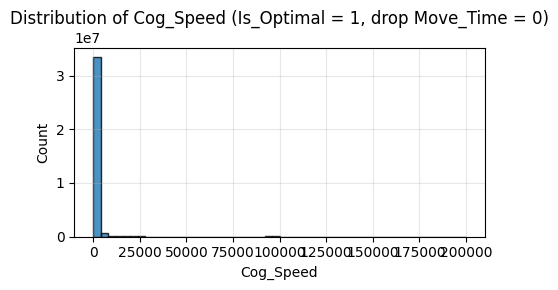

Bin: 0.00  -  3999.40  Counts: 33586347
Bin: 3999.40  -  7998.80  Counts: 636525
Bin: 7998.80  -  11998.20  Counts: 168975
Bin: 11998.20  -  15997.60  Counts: 65011
Bin: 15997.60  -  19997.00  Counts: 38430
Bin: 19997.00  -  23996.40  Counts: 18147
Bin: 23996.40  -  27995.80  Counts: 17273
Bin: 27995.80  -  31995.20  Counts: 12959
Bin: 31995.20  -  35994.60  Counts: 12152
Bin: 35994.60  -  39994.00  Counts: 3706
Bin: 39994.00  -  43993.40  Counts: 1339
Bin: 43993.40  -  47992.80  Counts: 6108
Bin: 47992.80  -  51992.20  Counts: 11191
Bin: 51992.20  -  55991.60  Counts: 5871
Bin: 55991.60  -  59991.00  Counts: 2023
Bin: 59991.00  -  63990.40  Counts: 554
Bin: 63990.40  -  67989.80  Counts: 91
Bin: 67989.80  -  71989.20  Counts: 6
Bin: 71989.20  -  75988.60  Counts: 6
Bin: 75988.60  -  79988.00  Counts: 14
Bin: 79988.00  -  83987.40  Counts: 19
Bin: 83987.40  -  87986.80  Counts: 59
Bin: 87986.80  -  91986.20  Counts: 3541
Bin: 91986.20  -  95985.59  Counts: 22009
Bin: 95985.59  -  99985

In [10]:
mask = (df_moves['Is_Optimal'] == 1) & np.isfinite(df_moves['Cog_Speed'])
speed_data = df_moves.loc[mask, 'Cog_Speed']

plt.figure(figsize=(5,3))
plt.hist(speed_data, bins=50, edgecolor='black', alpha=0.8)
plt.xlabel('Cog_Speed')
plt.ylabel('Count')
plt.title('Distribution of Cog_Speed (Is_Optimal = 1, drop Move_Time = 0)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

counts, edges = np.histogram(speed_data, bins = 50)
for i in range(len(counts)):
    print(f"Bin: {edges[i]:.2f}  -  {edges[i+1]:.2f}  Counts: {counts[i]}")

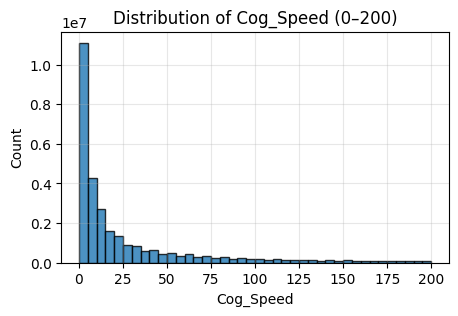

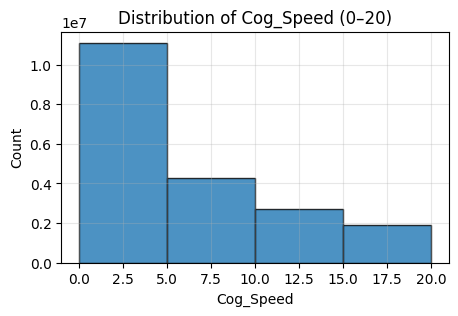

In [11]:
speed_focus0 = speed_data[speed_data <= 200]
speed_focus1 = speed_data[speed_data <= 20]
# 0-200
plt.figure(figsize=(5,3))
plt.hist(speed_focus0, bins=40, edgecolor='black', alpha=0.8)
plt.xlabel('Cog_Speed')
plt.ylabel('Count')
plt.title('Distribution of Cog_Speed (0–200)')
plt.grid(alpha=0.3)
plt.show()
# 0-20
plt.figure(figsize=(5,3))
plt.hist(speed_focus1, bins=4, edgecolor='black', alpha=0.8)
plt.xlabel('Cog_Speed')
plt.ylabel('Count')
plt.title('Distribution of Cog_Speed (0–20)')
plt.grid(alpha=0.3)
plt.show()

In [12]:
print(speed_focus1.nunique())
len(speed_focus1)

1997


19974273

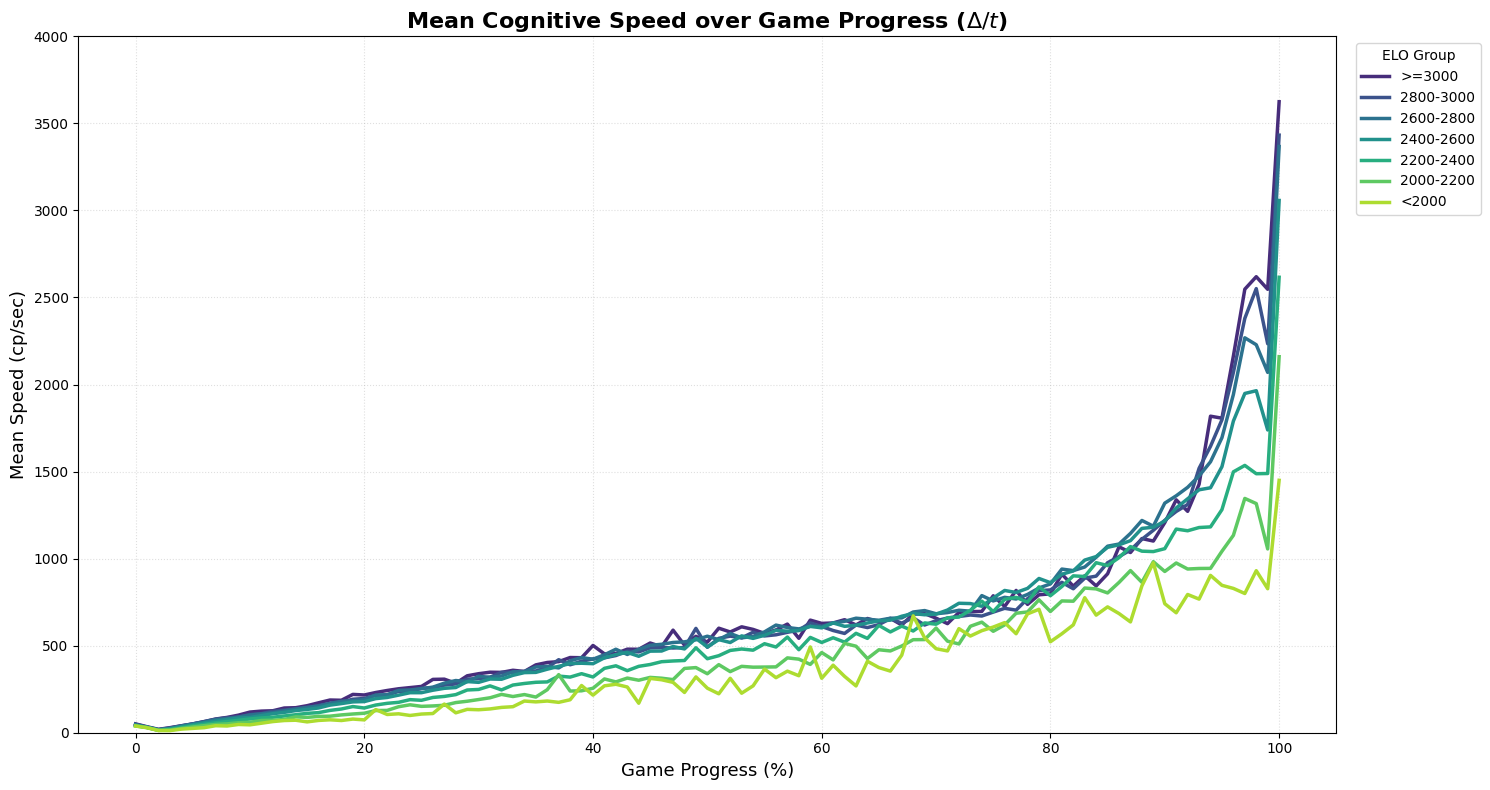

In [13]:
distinct_palette = sns.color_palette("viridis", len(elo_order))
color_map = dict(zip(elo_order, distinct_palette))

mask = (df_moves['Is_Optimal'] == 1) & np.isfinite(df_moves['Cog_Speed'])
time_complex = df_moves[mask].copy()

# 分箱
time_complex['Progress_Bin'] = (time_complex['Progress'] * 100).astype(int)

agg_metrics = time_complex.groupby(['ELO_Group', 'Progress_Bin'])['Cog_Speed'].agg(
    mean='mean'
).reset_index()

fig, ax = plt.subplots(figsize=(15, 8))
for group in elo_order:
    g_data = agg_metrics[agg_metrics['ELO_Group'] == group]
    ax.plot(g_data['Progress_Bin'], g_data['mean'], 
             color=color_map[group], linewidth=2.5, label=group)

ax.set_title(r'Mean Cognitive Speed over Game Progress ($\Delta/t$)', fontsize=16, fontweight='bold')
ax.set_xlabel('Game Progress (%)', fontsize=13)  # 【新增】：把原本在下面那张图的 X 轴标签补上来
ax.set_ylabel('Mean Speed (cp/sec)', fontsize=13)
# 均值天花板设为 4000
ax.set_ylim(0, 4000)  
ax.grid(True, linestyle=':', alpha=0.4)

ax.legend(title='ELO Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

感觉还需要在这里立马插入横坐标为progress 纵坐标分别为Δ_top5 和 思考时间的图         
横坐标为Δ_top5 在 figure1.ipynb里

In [15]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'Judgment_Raw', 'Is_Error',
       'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal',
       'Remain_Time', 'Time_Group', 'Move_Time', 'Game_Length', 'Progress',
       'Relative_Stage(temp)', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'Cog_Speed'],
      dtype='object')

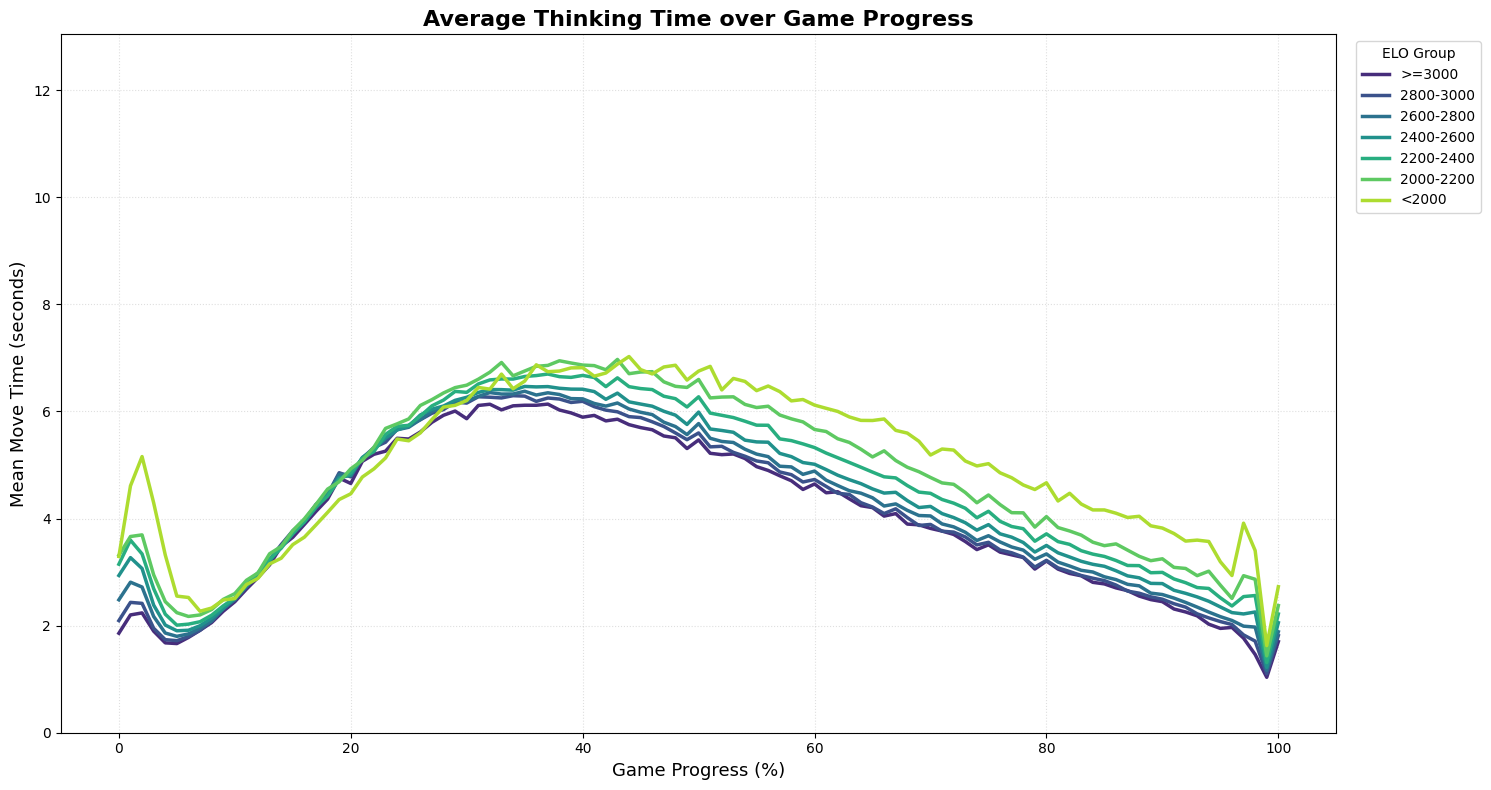

In [16]:
mask = df_moves['Is_Forced'] != 1
plot_df = df_moves[mask].copy()

# 2. 对 Progress 进行分箱（Progress 是 0.0 到 1.0 的浮点数）
# 乘以 100 并取整，将其转化为 0-100% 的整数分箱
plot_df['Progress_Bin'] = (plot_df['Progress'] * 100).astype(int)

# 按 ELO 分组和进度分箱，计算平均 Move_Time
agg_trends = plot_df.groupby(['ELO_Group', 'Progress_Bin'])['Move_Time'].agg(
    mean_time='mean'
).reset_index()

distinct_palette = sns.color_palette("viridis", len(elo_order))
color_map = dict(zip(elo_order, distinct_palette))
fig, ax = plt.subplots(figsize=(15, 8))
for group in elo_order:
    g_data = agg_trends[agg_trends['ELO_Group'] == group]
    # 排序确保线条从开局到残局连续
    g_data = g_data.sort_values('Progress_Bin')  
    ax.plot(g_data['Progress_Bin'], g_data['mean_time'], 
            color=color_map[group], linewidth=2.5, label=group)

ax.set_title('Average Thinking Time over Game Progress', fontsize=16, fontweight='bold')
ax.set_xlabel('Game Progress (%)', fontsize=13)
ax.set_ylabel('Mean Move Time (seconds)', fontsize=13)
# 限制 Y 轴范围：为了看清主体趋势，建议设为 0 到 30s 或根据你数据调整
# 因为平均思考时间通常不会超过 30 秒，设太高会压扁曲线
ax.set_ylim(0, plot_df['Move_Time'].mean() * 3) 

ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(title='ELO Group', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [20]:
del mask
gc.collect()

16258

In [17]:
# Move_Time 列值为 0 的比例
(df_moves['Move_Time']==0).mean()

np.float64(1.6016485448142062e-08)

下面的代码是加上分位数思考时间 感觉意义不是特别大

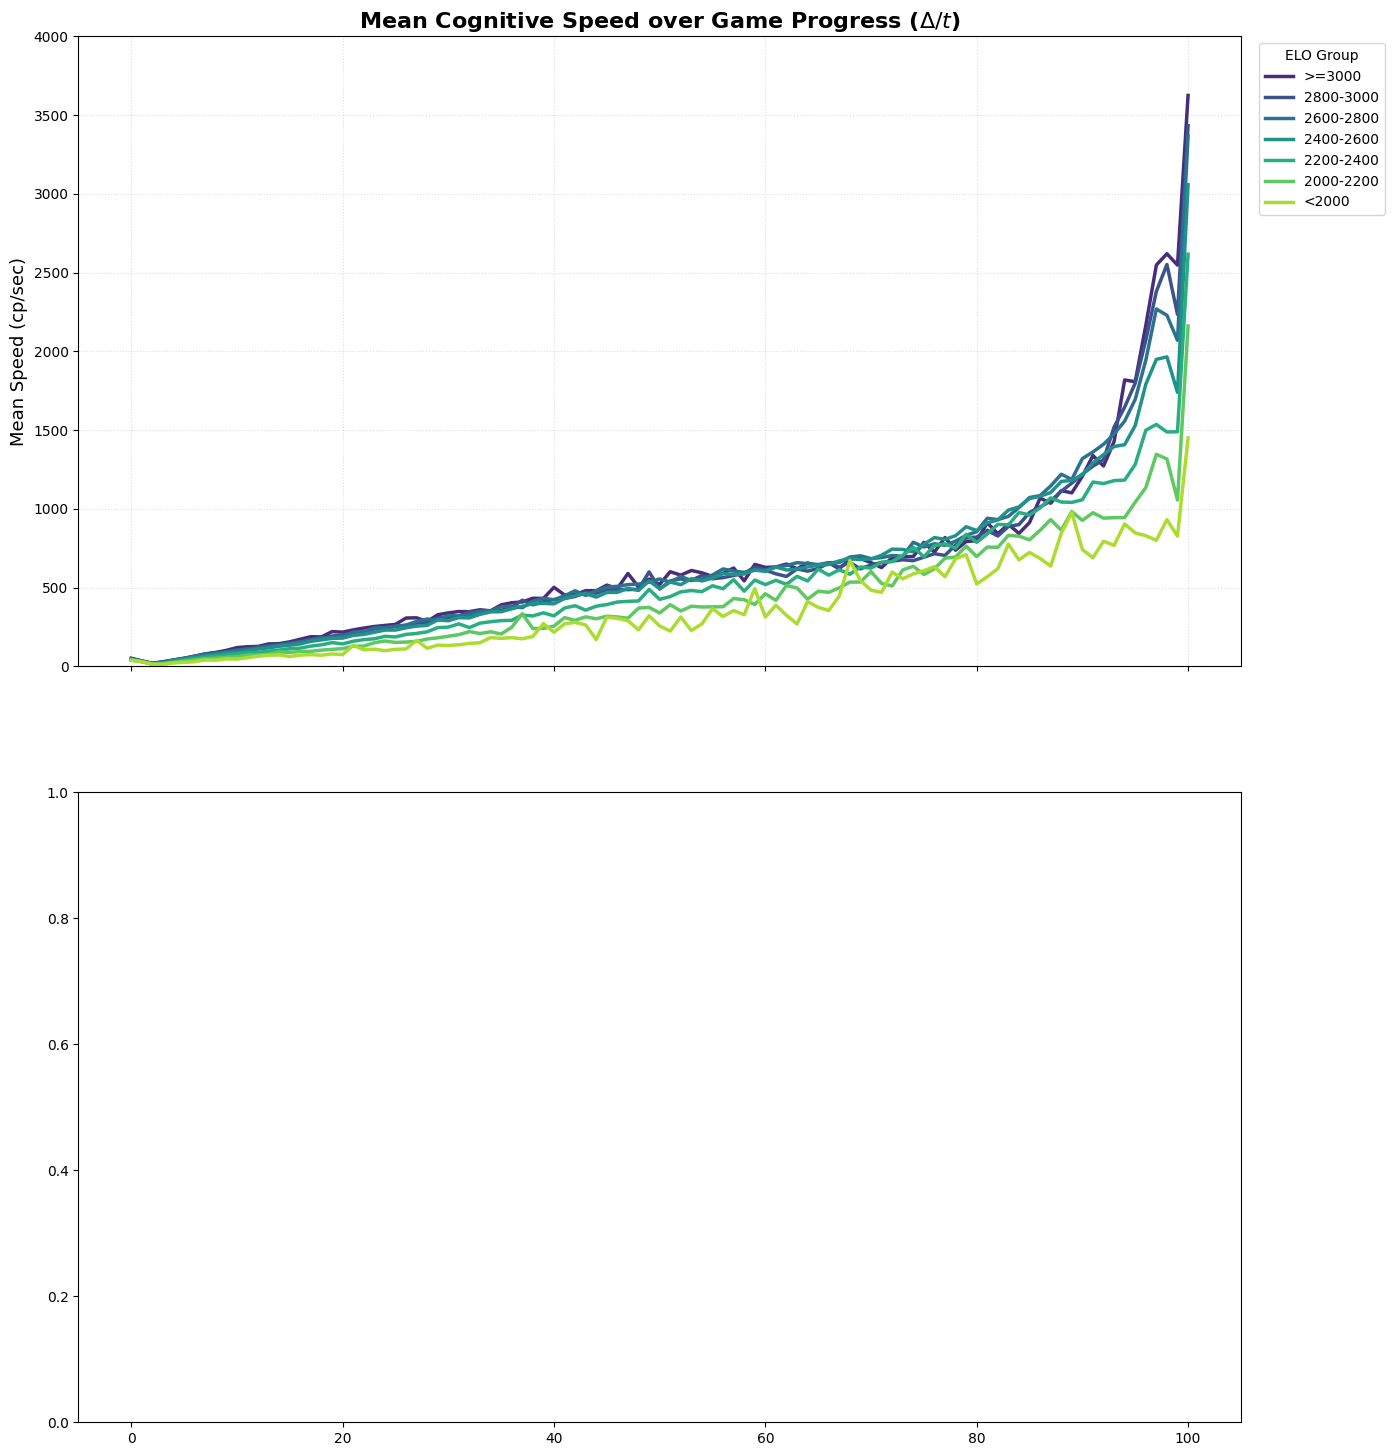

In [ ]:
# 换成渐变色板; reverse=True: 最高分段颜色最深
distinct_palette = sns.color_palette("viridis", len(elo_order))
color_map = dict(zip(elo_order, distinct_palette))
# 过滤数据
mask = (df_moves['Is_Optimal'] == 1) & np.isfinite(df_moves['Cog_Speed'])
time_complex = df_moves[mask].copy()

# 分箱 50 个
time_complex['Progress_Bin'] = (time_complex['Progress'] * 50).astype(int)
# # 聚合统计：0.25 0.5 0.75三个核心分位数
# agg_metrics = time_complex.groupby(['ELO_Group', 'Progress_Bin'])['Cog_Speed'].agg(
#     mean='mean',
#     q25=lambda x: x.quantile(0.25),
#     q50='median',
#     q75=lambda x: x.quantile(0.75)
# ).reset_index()
#fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 18), sharex=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 18), sharex=True)


# 均值对比图
for group in elo_order:
    g_data = agg_metrics[agg_metrics['ELO_Group'] == group]
    ax1.plot(g_data['Progress_Bin'], g_data['mean'], 
             color=color_map[group], linewidth=2.5, label=group)

ax1.set_title(r'Mean Cognitive Speed over Game Progress ($\Delta/t$)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Mean Speed (cp/sec)', fontsize=13)
# 均值天花板设为 4000 (过滤掉 inf 和非最优步后)
ax1.set_ylim(0, 4000)  
ax1.grid(True, linestyle=':', alpha=0.4)
ax1.legend(title='ELO Group', bbox_to_anchor=(1.01, 1), loc='upper left')

# 分位数分布图
# for group in elo_order:
#     g_data = agg_metrics[agg_metrics['ELO_Group'] == group]
#     color = color_map[group]
    
#     # q50 实线
#     ax2.plot(g_data['Progress_Bin'], g_data['q50'], color=color, 
#              linestyle='-', linewidth=3, alpha=0.9)
    
#     # q25 & q75 虚线
#     ax2.plot(g_data['Progress_Bin'], g_data['q25'], color=color, 
#              linestyle='--', linewidth=1.0, alpha=0.9)
#     ax2.plot(g_data['Progress_Bin'], g_data['q75'], color=color, 
#              linestyle='--', linewidth=1.0, alpha=0.9)

# ax2.set_title(r'Quantile Dynamics (Solid: Median ; Dash: 0.25, 0.75 Percentiles)', fontsize=16, fontweight='bold')
# ax2.set_ylabel('Cognitive Speed (cp/sec)', fontsize=13)
# ax2.set_xlabel('Game Progress (%)', fontsize=13)
# ax2.set_ylim(0, 300)  
# ax2.grid(True, linestyle=':', alpha=0.4)

# plt.tight_layout()
# plt.show()

## Complexity to Blunder/Mistake

In [22]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'Judgment_Raw', 'Is_Error',
       'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal',
       'Remain_Time', 'Time_Group', 'Move_Time', 'Game_Length', 'Progress',
       'Relative_Stage(temp)', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'Cog_Speed'],
      dtype='object')

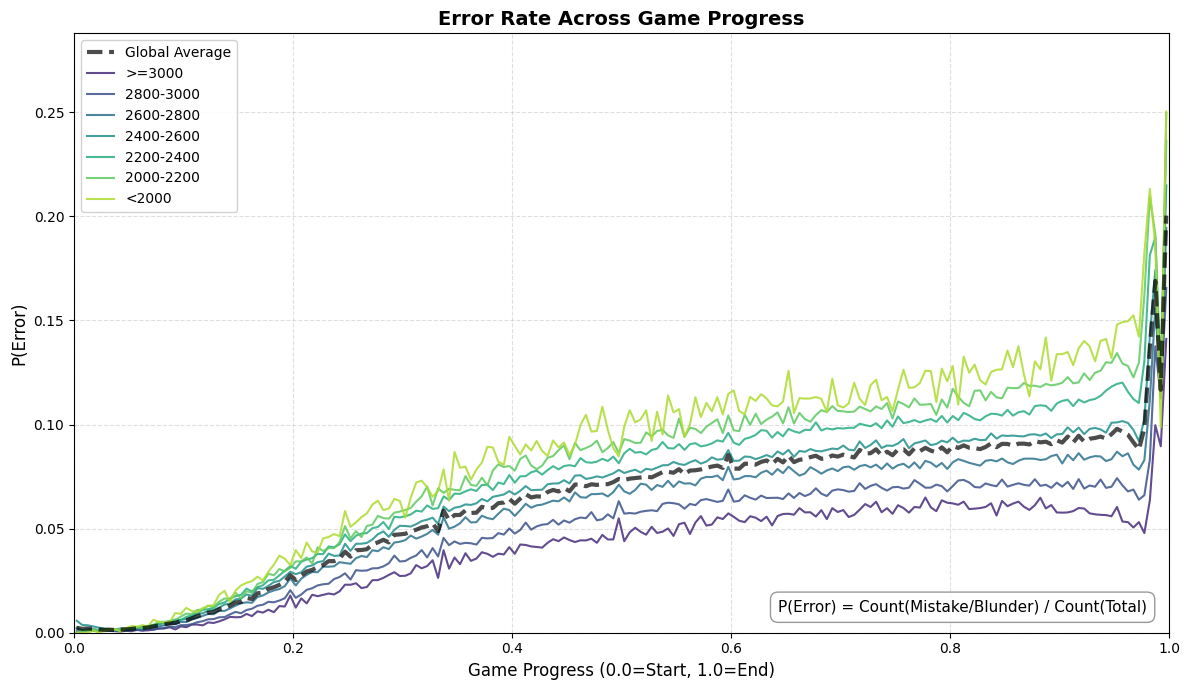

In [24]:
def plot_error_rate_by_progress_fast(df, bins=80):    
    # 分箱计算
    bin_indices = np.clip((df['Progress'].values * bins).astype(int), 0, bins - 1)
    
    # 避免超出内存，仅提取要用的数据
    temp_df = pd.DataFrame({'ELO_Group': df['ELO_Group'].values, 'Bin_Idx': bin_indices, 'Is_Error': df['Is_Error'].values})
    
    # 各个 ELO 组的统计量
    group_stats = temp_df.groupby(['ELO_Group', 'Bin_Idx'], observed=False)['Is_Error'].agg(['sum', 'count']).reset_index()
    group_stats['Error_Rate'] = group_stats['sum'] / group_stats['count']
    group_stats['Progress_Mid'] = (group_stats['Bin_Idx'] + 0.5) / bins

    # 全局 (Global) 的统计量， 用已聚合的 group_stats 二次聚合
    global_stats = group_stats.groupby('Bin_Idx')[['sum', 'count']].sum().reset_index()
    global_stats['Error_Rate'] = global_stats['sum'] / global_stats['count']
    global_stats['Progress_Mid'] = (global_stats['Bin_Idx'] + 0.5) / bins

    plt.figure(figsize=(12, 7))
    ax = plt.gca()
    
    # 画全局均线 (加粗、黑色、虚线，放在底层或顶层都可以，这里设为较高的 zorder 让它明显一点)
    ax.plot(global_stats['Progress_Mid'], global_stats['Error_Rate'], 
        color='black', linestyle='--', linewidth=3, alpha=0.7, label='Global Average',zorder=3)
    # ELO 分组线
    for i, group in enumerate(elo_order):
        group_data = group_stats[group_stats['ELO_Group'] == group]
        group_data = group_data.sort_values('Progress_Mid')
        
        ax.plot(group_data['Progress_Mid'],group_data['Error_Rate'], 
            color=distinct_palette[i], linewidth=1.5, alpha=0.85, label=group,zorder=2)
    
    plt.title("Error Rate Across Game Progress", fontsize=14, fontweight='bold')
    plt.xlabel("Game Progress (0.0=Start, 1.0=End)", fontsize=12)
    plt.ylabel("P(Error)", fontsize=12)
    plt.xlim(0, 1)
    max_y = max(group_stats['Error_Rate'].max(), global_stats['Error_Rate'].max())
    plt.ylim(0, max_y * 1.15) 
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc='upper left', framealpha=0.9)
    text_str = "P(Error) = Count(Mistake/Blunder) / Count(Total)"
    props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    ax.text(0.98, 0.03, text_str, transform=ax.transAxes, fontsize=11,verticalalignment='bottom', horizontalalignment='right', bbox=props, zorder=4)

    plt.tight_layout()
    plt.show()

plot_error_rate_by_progress_fast(df_moves, bins=200)

In [ ]:
def plot_error_rate_with_tau_markers(df, delta_col='Δ', max_delta=500, bins=100): 
    # 极速分箱逻辑保持不变
    vals = np.clip(df[delta_col].values, 0, max_delta)
    bin_indices = np.clip((vals / max_delta * bins).astype(int), 0, bins - 1)
    
    temp_df = pd.DataFrame({
        'ELO_Group': df['ELO_Group'].values, 
        'Bin_Idx': bin_indices, 
        'Is_Error': df['Is_Error'].values
    })
    
    group_stats = temp_df.groupby(['ELO_Group', 'Bin_Idx'], observed=False)['Is_Error'].agg(['sum', 'count']).reset_index()
    group_stats['Error_Rate'] = group_stats['sum'] / group_stats['count']
    bin_width = max_delta / bins
    group_stats['Delta_Mid'] = (group_stats['Bin_Idx'] + 0.5) * bin_width

    plt.figure(figsize=(12, 7))
    ax = plt.gca()
    
    # 画 ELO 分组线，并在 tau 处打点
    for i, group in enumerate(elo_order):
        group_data = group_stats[group_stats['ELO_Group'] == group]
        group_data = group_data.sort_values('Delta_Mid')
        color = distinct_palette[i]
        tau_val = τ_map[group]
        
        # 画主线
        ax.plot(group_data['Delta_Mid'], group_data['Error_Rate'], 
                color=color, linewidth=1.8, alpha=0.8, label=f"{group}")
        
        # 寻找距离 tau 最近的 x 坐标点，为了画那个点
        closest_idx = (np.abs(group_data['Delta_Mid'] - tau_val)).argmin()
        closest_row = group_data.iloc[closest_idx]
        
        # 在线上画一个显眼的实心圆点代表 tau
        ax.plot(closest_row['Delta_Mid'], closest_row['Error_Rate'], 
                marker='o', markersize=8, color=color, markeredgecolor='white', markeredgewidth=1.5, zorder=5)
        
        # 画一根淡淡的垂直虚线指向 X 轴，强调 tau 的位置
        ax.vlines(x=tau_val, ymin=0, ymax=closest_row['Error_Rate'], 
                  color=color, linestyle=':', alpha=0.5, zorder=1)

    plt.title(f"Error Rate Across {delta_col} (Dots represent Group-specific $\\tau$ thresholds)", fontsize=14, fontweight='bold')
    plt.xlabel(f"{delta_col} (cp)", fontsize=12)
    plt.ylabel("P(Error)", fontsize=12)
    
    plt.xlim(0, max_delta)
    # 只看 500cp 以内，所以 Y 轴最高基本在 0.25 左右，动态截取让图更好看
    max_y = group_stats['Error_Rate'].max()
    plt.ylim(0, max_y * 1.1) 
    
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc='upper left', framealpha=0.9, title='ELO Group')
    
    text_str = "Circular markers indicate the calibrated $\\tau$ value for each group."
    props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    ax.text(0.98, 0.90, text_str, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='right', bbox=props, zorder=4)

    plt.tight_layout()
    plt.show()

# 截断在 500cp，看最核心的决策区
# plot_error_rate_with_tau_markers(complex_drop_force, delta_col='Δ', max_delta=1000, bins=80)

def plot_error_rate_with_tau_markers_normalized(df, delta_col='Δ', max_delta=500, bins=100): 
    # 极速分箱逻辑保持不变
    vals = np.clip(df[delta_col].values, 0, max_delta)
    bin_indices = np.clip((vals / max_delta * bins).astype(int), 0, bins - 1)
    
    temp_df = pd.DataFrame({
        'ELO_Group': df['ELO_Group'].values, 
        'Bin_Idx': bin_indices, 
        'Is_Error': df['Is_Error'].values
    })
    
    group_stats = temp_df.groupby(['ELO_Group', 'Bin_Idx'], observed=False)['Is_Error'].agg(['sum', 'count']).reset_index()
    group_stats['Error_Rate'] = group_stats['sum'] / group_stats['count']
    bin_width = max_delta / bins
    group_stats['Delta_Mid'] = (group_stats['Bin_Idx'] + 0.5) * bin_width

    plt.figure(figsize=(12, 7))
    ax = plt.gca()
    
    print(f"{'ELO Group':<12} | {'Marker X (≈τ)':<15} | {'Marker Y (P/A)':<15}")
    print("-" * 50)

    # 画 ELO 分组线，并在 tau 处打点
    max_y_plotted = 0 # 用于动态调整Y轴上限
    
    for i, group in enumerate(elo_order):
        # 使用 copy 防止修改原始 warning
        group_data = group_stats[group_stats['ELO_Group'] == group].copy()
        group_data = group_data.sort_values('Delta_Mid')
        color = distinct_palette[i]
        
        tau_val = elo_params[group]['tau']
        A_val = elo_params[group]['A']
        
        # 【核心修改点】：纵坐标除以 A 进行归一化
        group_data['Normalized_Error'] = group_data['Error_Rate'] / A_val
        
        # 记录用于设置 Y 轴上限的最大值
        current_max = group_data['Normalized_Error'].max()
        if current_max > max_y_plotted:
            max_y_plotted = current_max

        # 画主线 (纵坐标已经是归一化后的了)
        ax.plot(group_data['Delta_Mid'], group_data['Normalized_Error'], 
                color=color, linewidth=1.8, alpha=0.8, label=f"{group}")
        
        # 寻找距离 tau 最近的 x 坐标点，为了画那个点
        closest_idx = (np.abs(group_data['Delta_Mid'] - tau_val)).argmin()
        closest_row = group_data.iloc[closest_idx]
        
        marker_x = closest_row['Delta_Mid']
        marker_y = closest_row['Normalized_Error']
        
        # 【核心修改点】：打印标点的坐标
        print(f"{group:<12} | {marker_x:<15.2f} | {marker_y:<15.4f}")
        
        # 在线上画一个显眼的实心圆点代表 tau
        ax.plot(marker_x, marker_y, 
                marker='o', markersize=8, color=color, markeredgecolor='white', markeredgewidth=1.5, zorder=5)
        
        # 画一根淡淡的垂直虚线指向 X 轴，强调 tau 的位置
        ax.vlines(x=tau_val, ymin=0, ymax=marker_y, 
                  color=color, linestyle=':', alpha=0.5, zorder=1)

    plt.title(f"Capacity-Normalized Error Rate Across {delta_col}", fontsize=14, fontweight='bold')
    plt.xlabel(f"{delta_col} (cp)", fontsize=12)
    plt.ylabel("Normalized P(Error) [ P / A ]", fontsize=12) # 更新了纵坐标标签
    
    plt.xlim(0, max_delta)
    # 动态调整 Y 轴上限，留出 10% 的余量
    plt.ylim(0, max_y_plotted * 1.1) 
    
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc='upper left', framealpha=0.9, title='ELO Group')
    
    text_str = (
        "Y-axis is normalized by group-specific capacity (A).\n"
        "Circular markers indicate the calibrated $\\tau$ value."
    )
    props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    ax.text(0.98, 0.90, text_str, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='right', bbox=props, zorder=4)

    plt.tight_layout()
    plt.show()

# 跑起来看看效果和打印的坐标值！
plot_error_rate_with_tau_markers_normalized(complex_drop_force, delta_col='Δ', max_delta=500, bins=100)